In [1]:
# https://cooltools.readthedocs.io/en/latest/notebooks/dots.html

import pandas as pd
import numpy as np
from itertools import chain

# Hi-C utilities imports:
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# Visualization imports:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from matplotlib.ticker import EngFormatter

# helper functions for plotting
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    """format ticks with genomic coordinates as human readable"""
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

In [2]:
cool_file = "CustardPyResults_Hi-C/Cooler_hg38/Control/cool/Control.multires.cool"

# 10 kb is a resolution at which one can clearly see "dots":
binsize = 10000
# Open cool file with Micro-C data:
clr = cooler.Cooler(f'{cool_file}::/resolutions/{binsize}')

In [3]:
%%time
# define genomic view that will be used to call dots and pre-compute expected

# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler.
hg38_arms = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()


CPU times: user 211 ms, sys: 10.5 ms, total: 222 ms
Wall time: 222 ms


In [10]:
hg38_chromsizes

name
chr1     248956422
chr2     242193529
chr3     198295559
chr4     190214555
chr5     181538259
chr6     170805979
chr7     159345973
chr8     145138636
chr9     138394717
chr10    133797422
chr11    135086622
chr12    133275309
chr13    114364328
chr14    107043718
chr15    101991189
chr16     90338345
chr17     83257441
chr18     80373285
chr19     58617616
chr20     64444167
chr21     46709983
chr22     50818468
chrX     156040895
chrY      57227415
chrM         16569
Name: length, dtype: int64

In [12]:
hg38_arms

,chrom,start,end,name
0,chr1,0,123400000,chr1_p
1,chr1,123400000,248956422,chr1_q
2,chr2,0,93900000,chr2_p
3,chr2,93900000,242193529,chr2_q
4,chr3,0,90900000,chr3_p
5,chr3,90900000,198295559,chr3_q
6,chr4,0,50000000,chr4_p
7,chr4,50000000,190214555,chr4_q
8,chr5,0,48800000,chr5_p
9,chr5,48800000,181538259,chr5_q


In [13]:
# intra-arm expected
expected = cooltools.expected_cis(
    clr,
#    view_df=hg38_arms,
    nproc=24,
)

INFO:root:creating a Pool of 24 workers
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [14]:
dots_df = cooltools.dots(
    clr,
    expected=expected,
#    view_df=hg38_arms,
    # how far from the main diagonal to call dots:
    max_loci_separation=10_000_000,
    nproc=24,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 24 workers
INFO:root:convolving 1821 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 29.442 sec ...
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
INFO:root:Determined thresholds for every lambda-bin ...
INFO:root:creating a Pool of 24 workers
INFO:root:convolving 1821 tiles to extract enriched pixels
INFO:root:creating a Pool

In [15]:
# create a functions that would return a series of rectangles around called dots
# in a specific region, and exposing importnat plotting parameters
def rectangles_around_dots(dots_df, region, loc="upper", lw=1, ec="cyan", fc="none"):
    """
    yield a series of rectangles around called dots in a given region
    """
    # select dots from the region:
    df_reg = bioframe.select(
        bioframe.select(dots_df, region, cols=("chrom1","start1","end1")),
        region,
        cols=("chrom2","start2","end2"),
    )
    rectangle_kwargs = dict(lw=lw, ec=ec, fc=fc)
    # draw rectangular "boxes" around pixels called as dots in the "region":
    for s1, s2, e1, e2 in df_reg[["start1", "start2", "end1", "end2"]].itertuples(index=False):
        width1 = e1 - s1
        width2 = e2 - s2
        if loc == "upper":
            yield patches.Rectangle((s2, s1), width2, width1, **rectangle_kwargs)
        elif loc == "lower":
            yield patches.Rectangle((s1, s2), width1, width2, **rectangle_kwargs)
        else:
            raise ValueError("loc has to be uppper or lower")

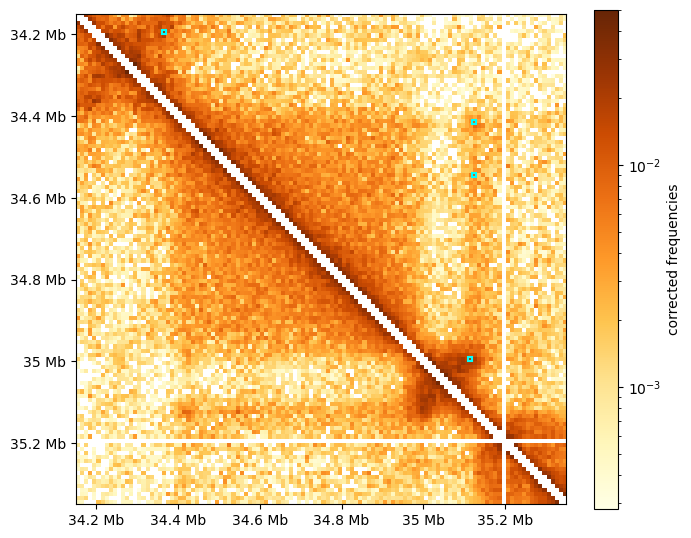

In [16]:
# define a region to look into as an example
start = 34_150_000
end = start + 1_200_000
region = ('chr17', start, end)

# heatmap kwargs
matshow_kwargs = dict(
    cmap='YlOrBr',
    norm=LogNorm(vmax=0.05),
    extent=(start, end, end, start)
)

# colorbar kwargs
colorbar_kwargs = dict(fraction=0.046, label='corrected frequencies')

# compute heatmap for the region
region_matrix = clr.matrix(balance=True).fetch(region)
for diag in [-1,0,1]:
    region_matrix = fill_diag(region_matrix, np.nan, i=diag)

# see viz.ipynb for details of heatmap visualization
f, ax = plt.subplots(figsize=(7,7))
im = ax.matshow( region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for box in rectangles_around_dots(dots_df, region, lw=1.5):
    ax.add_patch(box)

In [19]:
dots_df

,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr1,6720000,6730000,chr1,6890000,6900000,35,13.376584,14.356255,15.486146,...,1.703990e-03,1.716681e-03,3.220425e-05,chr1,6.710000e+06,6.880000e+06,1,2,chr1,chr1
1,chr1,7040000,7050000,chr1,7210000,7220000,29,10.456277,11.211397,10.393233,...,5.616104e-03,5.377117e-03,4.004987e-03,chr1,7.040000e+06,7.210000e+06,3,1,chr1,chr1
2,chr1,7980000,7990000,chr1,8310000,8320000,113,24.310219,32.874693,38.162889,...,7.179607e-19,6.923549e-19,2.724529e-34,chr1,7.989167e+06,8.320000e+06,5,12,chr1,chr1
3,chr1,8130000,8140000,chr1,8310000,8320000,52,21.412129,28.291293,21.075361,...,8.583858e-03,7.482617e-05,5.181335e-05,chr1,8.133333e+06,8.303333e+06,7,3,chr1,chr1
4,chr1,8560000,8570000,chr1,8710000,8720000,60,26.876362,30.915815,34.765629,...,1.243436e-04,2.217202e-02,9.302857e-05,chr1,8.558000e+06,8.716000e+06,9,5,chr1,chr1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,chrX,130390000,130400000,chrX,130910000,130920000,33,6.633980,9.135312,6.508883,...,8.402379e-06,1.219556e-07,7.647440e-12,chrX,1.303850e+08,1.309100e+08,156,2,chrX,chrX
5861,chrX,134520000,134530000,chrX,134750000,134760000,47,17.555953,22.170496,21.211018,...,1.692559e-03,1.683509e-03,1.151016e-05,chrX,1.345200e+08,1.347500e+08,159,1,chrX,chrX
5862,chrX,136030000,136040000,chrX,136160000,136170000,50,18.119037,16.230675,26.667013,...,1.365013e-06,2.191605e-02,9.916957e-07,chrX,1.360250e+08,1.361550e+08,161,2,chrX,chrX
5863,chrX,150770000,150780000,chrX,151000000,151010000,32,8.787057,8.283446,12.541432,...,2.325190e-05,6.133696e-04,1.209419e-05,chrX,1.507700e+08,1.510000e+08,165,1,chrX,chrX


In [18]:
dots_df_all = cooltools.dots(
    clr,
    expected=expected,
#    view_df=hg38_arms,
    max_loci_separation=10_000_000,
    clustering_radius=None,  # None - implies no clustering
    cluster_filtering=False,  # ignored when clustering is off
    nproc=4,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1821 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 119.994 sec ...
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
INFO:root:Determined thresholds for every lambda-bin ...
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1821 tiles to extract enriched pixels
INFO:root:creating a Pool 

In [ ]:
f, ax = plt.subplots(figsize=(7,7))
# draw heatmap
im = ax.matshow(region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for rect in chain(
        rectangles_around_dots(dots_df, region, lw=1.5),  # clustered & filtered
        rectangles_around_dots(dots_df_all, region, loc="lower", ec="blue"),  # unclustered
    ):
    ax.add_patch(rect)

In [ ]:
# function to draw kernels:
def draw_kernel(kernel, axis=None, cmap='viridis'):
    if axis is None:
        f, axis = plt.subplots()
    # kernel:
    imk = axis.imshow(
                    kernel[::-1,::-1],  # flip it, as in convolution
                    alpha=0.85,
                    cmap=cmap,
                    interpolation='nearest')
    # draw a square around the target pixel:
    x0 = kernel.shape[0] // 2 - 0.5
    y0 = kernel.shape[1] // 2 - 0.5
    rect = patches.Rectangle((x0, y0), 1, 1, lw=1, ec='r', fc='r')
    axis.add_patch(rect)

    # clean axis:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xticklabels('',visible=False)
    axis.set_yticklabels('',visible=False)
    axis.set_title("{} kernel".format(ktype),fontsize=16)
    # add a checkerboard to highlight pixels:
    checkerboard = np.add.outer(range(kernel.shape[0]),
                                range(kernel.shape[1])) % 2
    # show it:
    axis.imshow(checkerboard,
            cmap='gray',
            interpolation='nearest',
            alpha=0.3)

    return imk

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000


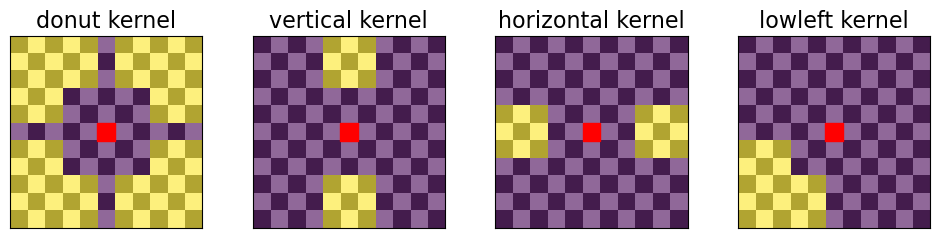

In [15]:
kernels = cooltools.api.dotfinder.recommend_kernels(binsize)

fig, axs = plt.subplots(ncols=4, figsize=(12,2.5))
for ax, (ktype, kernel) in zip(axs, kernels.items()):
    imk = draw_kernel(kernel, ax)

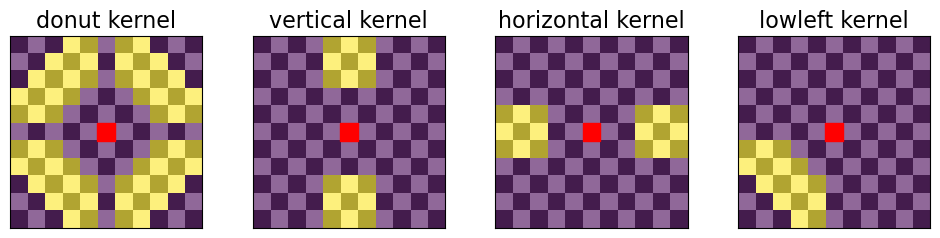

In [16]:
# create a grid of coordinates from -5 to 5, to define round kernels
# see https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html for details
half = 5  # half width of the kernel
x, y = np.meshgrid(
    np.linspace(-half, half, 2*half + 1),
    np.linspace(-half, half, 2*half + 1),
)
# now define a donut-like mask as pixels between 2 radii: sqrt(7) and sqrt(30):
mask = (x**2+y**2 > 7) & (x**2+y**2 <= 30)
mask[:,half] = 0
mask[half,:] = 0

# lowleft mask - zero out neccessary parts
mask_ll = mask.copy()
mask_ll[:,:half] = 0
mask_ll[half:,:] = 0

# new kernels with more round donut and lowleft masks:
kernels_round = {'donut': mask,
 'vertical': kernels["vertical"].copy(),
 'horizontal': kernels["horizontal"].copy(),
 'lowleft': mask_ll}

# plot rounded kernels
fig, axs = plt.subplots(ncols=4, figsize=(12,2.5))
for ax, (ktype, kernel) in zip(axs, kernels_round.items()):
    imk = draw_kernel(kernel, ax)

In [17]:
#### call dots using redefined kernels (without clustering)

dots_round_df_all = cooltools.dots(
    clr,
    expected=expected,
    view_df=hg38_arms,
    kernels=kernels_round, # provide custom kernels
    max_loci_separation=10_000_000,
    clustering_radius=None,
    nproc=4,
)

/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:1551: UserWarning: Compatibility checks for 'kernels' are not fully implemented yet, use at your own risk
  warnings.warn(
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1781 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 99.368 sec ...
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/opt/micromamba/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
INFO:root:Determined thresholds for every lambda-bin ...
INFO:root:

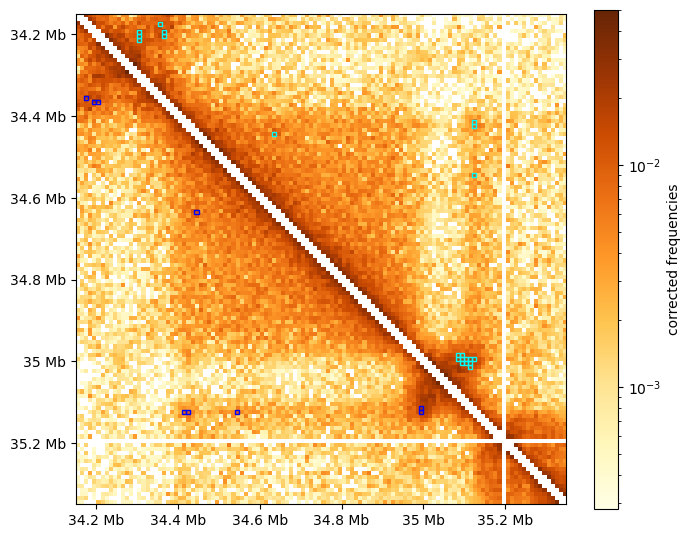

In [18]:
f, ax = plt.subplots(figsize=(7,7))
# draw heatmap
im = ax.matshow(region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for rect in chain(
        rectangles_around_dots(dots_round_df_all, region),
        rectangles_around_dots(dots_df_all, region, loc="lower", ec="blue"),
    ):
    ax.add_patch(rect)